In [1]:
import os
import sys
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatch
import matplotlib.path as mpath
import pandas as pd
from PIL import Image
from glob import glob
from tools.fdm.src import fdm3Blom, mfgrid
from tools.etc import color_cycler, logo, descr, pickleto, picklefrom
from tools.analytic.nsec1 import Nsec1
from tools.coords import profile_geometry as lgt
import mf6lab.Projects.ARK_RWS.src.ARK_tools as atools
from importlib import reload


dirs = atools.dirs
raai_colors = atools.raai_colors
leg_colors = atools.leg_colors
muT_mu10C = atools.muT_mu10C
point_line_distance = atools.point_line_distance
point_polyline_distance = atools.point_polyline_distance


print("=== Current Session ===")
print("os.getcwd():", os.getcwd())
print("sys.executable: ", sys.executable)
print("sys.path:")
for p in sys.path:
    print(p)
print("=======================")


NOTEBOOK_NAME = "ARK_XS_model.ipynb"
print(f"NOTEBOOK_NAME = '{NOTEBOOK_NAME}'")


# --- dtypes for boundary conditions of Fdm3
dtypes = fdm3Blom.Fdm3.dtypes

temp_ARK_stats = picklefrom(os.path.join(dirs.data, 'temp_ARK_stats.pkl'))

print("Project directory namespace:")
descr(dirs)

def mask_fr_path(gr, path):
    """Rerturn a 3D mask given a 2D [x,z] path"""
    mask_zx = path.contains_points(np.c_[gr.XM.ravel(), gr.ZM.ravel()]).reshape(gr.shape)
    return mask_zx * gr.const(1, dtype=bool)
    


loading mfpath.py

os.getcwd(): /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/notebooks
sys.executable =  /Users/Theo/Development/python/mf6_tools/mf6lab/.venv/bin/python
ARGV ['/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages/ipykernel_launcher.py', '--f=/Users/Theo/Library/Jupyter/runtime/kernel-v315cfbe5b4cc50e5cd79acf76a422bb612e44455c.json']
sys.path:
/Users/Theo/GRWMODELS/python/tools
./modules/
/Users/Theo/GRWMODELS/python/bootstraps
/Library/Frameworks/Python.framework/Versions/3.13/lib/python313.zip
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/lib-dynload

/Users/Theo/Development/python/mf6_tools/mf6lab/.venv/lib/python3.13/site-packages
__editable__.mf6lab-0.1.finder.__path_hook__
__editable__.tools-0.1.finder.__path_hook__

=== Current Session ===
os.getcwd(): /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/notebooks
sys

# Model

In [4]:
# Cross section model basid on best estimates of conductivities
# TODO: adapt

# --- Choose a case for the current run (raai, 'zomer'|'winter'))
case = (5, 'winter')
test = case[1] == 'test'

temp_ARK_max  = temp_ARK_stats['max']['temp']
temp_ARK_mean = temp_ARK_stats['mean']['temp']
temp_ARK_min  = temp_ARK_stats['min']['temp']

# === Basic model properties (Size, depths, fixed heads) ===
b_model = 10000. # --- Half width of model
b_ARK   = 50.    # --- Canal width
z_ARK   = -6.5   # --- Bottom elevation of canal
b_wellen = 300.  # --- Width the area next to the canal with the bulk of the wellen
b_kade = 20.     # --- Width of the road next to the canal
b_damw = 0.5     # --- Width of the sheet piling
b_owt = 19.2     # --- Width of underwater talud
h_owt = 2.4      # --- Height of the onderwater talud
h_ARK = -0.4     # --- Water level ARK

xPr  = [0, b_ARK - b_owt, b_ARK, b_ARK]
zPr =  [z_ARK, z_ARK, z_ARK + h_owt, h_ARK]

ARK_prof = lgt.Ditch_profile(xPr, zPr)

columns = ['raai-seiz', 'temp_ARK', 'c_ARK_slib', 'c_drainage', 'c_wellen', 'b_wellen', 'h_pold', 'kv_NK']
data =[
    #                 Tmp          cARK   cdr    cwel  bwel  hpol   kv_NK
    [( 4, 'zomer'),   temp_ARK_max,  3.0,  100.,  225.,  300, -2.3, 0.001],
    [( 4, 'winter'),  temp_ARK_min,  100.,  225.,  300, -2.3, 0.001],         
    [( 5, 'zomer'),   temp_ARK_max,  6.0,  125.,  250.,  300, -2.3, 0.002],    # 8.0
    [( 5, 'winter'),  temp_ARK_min, 20.0,  125,   500.,  300, -2.3, 0.002],
    [( 6, 'zomer'),   temp_ARK_max, 23.0,  125., 1000., 300, -2.6, 0.0008],
    [( 6, 'winter'),  temp_ARK_min, 30.0,  125., 1500., 300, -2.6, 0.0008],
    [(11, 'zomer'),   temp_ARK_max, 7.5,   300.,  300.,  500, -2.3, 0.001], 
    [(11, 'winter'),  temp_ARK_min, 23.0,  300., 1000.,  500, -2.3, 0.001],
    
    #                 Tmp  cARK   cdr    cwel  bwel  hpol   kv_NK
    [( 0, 'basis'),   temp_ARK_mean, 8.,    125.,   50, 300, -2.3, 0.002],
    
    [( 0, 'test'),    temp_ARK_mean, 20.0, 1000., 1.0e6,  300, -2.3, 1000.0],
]
c_values = pd.DataFrame(data=data, columns=columns)
c_values.index = c_values['raai-seiz']
c_values = c_values.drop(columns=['raai-seiz'])

temp_ARK, c_ARK_slib, c_drainage, c_wellen,  b_wellen, h_pold, kv_NK = c_values.loc[[case], [
    'temp_ARK', 'c_ARK_slib', 'c_drainage','c_wellen',  'b_wellen', 'h_pold', 'kv_NK']].iloc[0]


# --- Definition of geological layers --> store in pd.DataFrame
columns = ['bkLaag', 'okLaag', 'kh', 'kv', 'geo', 'lith', 'fc']
if test: # --- test set for vertically isotropic layers, vertical resistance at all
    data = np.array([[ -2., -2.5, 10., 1.e4,  'Echteld',  'zk - k', 'sandybrown'],
                    [ -2.5, -6.0, 10., 1.e4,  'Niewkoop', 'veen',   'goldenrod'],
                    [ -6.0, -50., 10., 1.e4,  'BX-DR',    'fz - gz','gold'],
                    [-50.,  -60., 10., 1.e4,  'Waalre',   'klei',   'lightgreen'],
                    [-60., -160., 10., 1.e4,  'Peize',    'gz',     'yellow']])
    
else: # --- Actual data (the latest in the sets specified here)
    data = np.array([[ -2.,  -2.5, 0.2, 0.02,  'Echteld',  'zk-k', 'sandybrown'],
                    [ -2.5, -6.0, 0.4, kv_NK,  'Niewkoop',  'veen',   'goldenrod'],
                    [ -6.00, -6.01, 15., 1.5, 'Spleet', 'water', 'blue'],
                    [ -6.01, -50.0, 15., 1.5,   'BX-DR',    'fz-gz','gold'],
                    [-50.,   -60.0, 0.2, 0.2,   'Waalre',   'klei',   'lightgreen'],                   
                    [-60.,  -160.0, 30., 10.,   'Peize',     'gz',   'yellow']])
    # data = np.array([[ -2.,  -2.5, 0.2, 0.02,  'Echteld',  'zk-k', 'sandybrown'],
    #                 [ -2.5, -6.0, 0.4, kv_NK,  'Niewkoop',  'veen',   'goldenrod'],
    #                 [ -6.0,  -50., 15., 1e3,   'BX-DR',    'fz-gz','gold'],
    #                 [-50.,   -60., 0.2, 1e3,   'Waalre',   'klei',   'lightgreen'],                   
    #                 [-60.,  -160., 30., 1e3,   'Peize',     'gz',   'yellow']])

index = ['Ech', 'NK', 'SP', 'BX', 'Wa', 'Pe']

lagen = pd.DataFrame(data, columns=columns, index=index)
lagen[columns[:4]] = lagen[columns[:4]].astype(float)

# --- Intersect lagen with ARK profile and store path in DataFrame.
for laag in lagen.index:
    zTop = lagen.loc[laag, 'bkLaag']
    zBot = lagen.loc[laag, 'okLaag']
    lagen.loc[laag, 'path'] = ARK_prof.layer_path(zTop, zBot, b_model)
    
# --- Add additional property columns
lagen[ 'D'] = lagen['bkLaag'] - lagen['okLaag']
lagen['kD'] = lagen['D'] * lagen['kh']
lagen[ 'c'] = lagen['D'] / lagen['kv']

strat_txt = [
    f"{'Laag':>9} {'top':>6} {'basis':>6} {'kh':>6} {'kv':>7}",
    f"{'':>9} {'m NAP':>6} {'m NAP':>6} {'m/d':>6} {'m/d':>7}",
]
for lg in lagen.index:
    rec = lagen.loc[lg]
    strat_txt.append(
    f"{rec['geo']:9} {rec['bkLaag']:6.1f} {rec['okLaag']:6.1f} {rec['kh']:6.2f} {rec['kv']:7.3f}"
    )
    
# --- screen elevation of piezometer in ARK
z_pb, x1_pb, x2_pb  = lagen.loc['BX', 'bkLaag'], b_ARK - 0.5, b_ARK + 1.0
z_damw = -10.    # --- Sheet piling bottom elevation

print('\n'.join(strat_txt))

     Laag    top  basis     kh      kv
           m NAP  m NAP    m/d     m/d
Echteld     -2.0   -2.5   0.20   0.020
Niewkoop    -2.5   -6.0   0.40   0.002
Spleet      -6.0   -6.0  15.00   1.500
BX-DR       -6.0  -50.0  15.00   1.500
Waalre     -50.0  -60.0   0.20   0.200
Peize      -60.0 -160.0  30.00  10.000


In [167]:
def get_analytical_props(gr, lagen, GHB, DRN):
    """Return aquifer props for analytical comparison.
    
    The hydraulic properties are obtained back from the
    model input data to verfiy the input's correctness.
    
    Returns
    -------
    kD: float
        transmissivity of the layers below the cover layer.
    c: float
        resistance of the cover layer (D/kv)
    cGHB: float
        median polder drainage resistance (adds to c in model)
        normally all values are the same unless changed in code.
        cGHB = dx / C [m/(d/m2])] = [d]        
    cDRN: float
        median resistance by the wellen (implemented by DRN) in the top of WVP1
        These DRNs leak parallel to GHB and, therefore reduce the overall
        vertical resistance in the model.
        normally all values are the same unless changed in code.
        cDRN = dx / C [m/(d/m2])] = [d]
    """
    wvps = lagen['okLaag'] <  lagen.loc['NK', 'okLaag'] # --- All layers below Nieuwkoop bottom
    sdps = lagen['okLaag'] >= lagen.loc['NK', 'okLaag'] # --- All layers above Nieuwkoop bottom

    kD = (lagen.loc[wvps, 'kh'] * lagen.loc[wvps, 'D']).sum()
    c  = (lagen.loc[sdps,  'D'] / lagen.loc[sdps, 'kv']).sum().round()
    
    cGHB = np.median(gr.DX.ravel()[GHB['Ig']] / GHB['C']).round(1) 
    cDRN = np.median(gr.DX.ravel()[DRN['Ig']] / DRN['C']).round(1)
    return kD, c, cGHB, cDRN

# === Not too simple Xsec ARK model for testing ====
# case = (4, 'winter')  # raai 4, winter
# Specify case above

# --- Get the values for this case
temp_ARK, c_ARK_slib, c_wellen, c_drainage, b_wellen = c_values.loc[[case],
                        ['temp_ARK', 'c_ARK_slib', 'c_wellen', 'c_drainage', 'b_wellen']].iloc[0]

# --- ARK_bottom resistance to achieve
# TODOc
c_ARK_slib_goal = 100.

# --- Resistance under water bench (onderwatertalud)
c_damw=50.


# --- Definition of geological layers in DataFrame generated above
print(lagen)
print()

# === The grid (combine specific z-coordinates, the layers and an overall refined enough grid)
z = np.unique(np.r_[z_damw, -3, -3.5, -4, -4.5, -5, -5.5, -6., -6.25, z_ARK, -6.75, -7, -7.5,
                    lagen['bkLaag'], lagen['okLaag'],
                    np.linspace(0, lagen.loc['Pe', 'okLaag'], 41)])[::-1] # make sure you get a nice distribution.

z = z[z <= lagen.loc['Ech', 'bkLaag']]

# --- The x-grid
x1_ = b_ARK - np.logspace(0, np.log10(b_ARK), 10)           # --- inside the ARK
x2_ = np.logspace(np.log10(b_ARK), np.log10(b_model), 50)   # --- outside the ARK
x3_ = b_ARK + np.array([-1, 1, 2]) * b_damw                 # --- details, side of canal

x = np.unique(np.hstack((0, 0.5, x1_, x2_, x3_, b_model - 1))) # --- combine all

y = np.linspace(0, -1000, 101)

gr = mfgrid.Grid(x, y, z)


# --- Mask for the piezometers in the ARK (within the sheet pilings)
iz_pb = gr.iz_below(z_pb)
ix_pb = np.searchsorted(gr.x, [x1_pb, x2_pb]) - 1
mask_pb = gr.const(0., bool)
mask_pb[iz_pb, 0, ix_pb] = True  # --- iy==0, so piezometers are in the first row

# === Matrix / cell properties
kh = gr.const(0)
kv = gr.const(0)

# --- Fill each geol layer
for lg in lagen.index:
    laag = lagen.loc[lg, :]    
    mask = mask_fr_path(gr, laag['path'])
    kh[mask] = laag['kh']
    kv[mask] = laag['kv']

# ---- The ARK water body
mask_ARK = mask_fr_path(gr, ARK_prof.path)

# --- The sludge layer is in the first cell below the water bottom
mask_ARK_slib = np.zeros(gr.shape,  dtype=bool)
mask_ARK_slib[1:] = np.logical_and(mask_ARK[:-1], np.logical_not(mask_ARK[1:])) # --- The trick!

# --- Proprotion of  model belonging to north versus belonging to south
# --- The north part of the model gets the goal resistance, south the initial one.
frac = 0.2
y_mid = gr.y[0] - frac * (gr.y[0] - gr.y[-1])

mask_ARK_slib_N = mask_ARK_slib & (gr.YM > y_mid) # --- top half of model
mask_ARK_slib_S = mask_ARK_slib & (gr.YM < y_mid) # --- bottom half of model


# --- The sheet pilings
mask_damw = (gr.ZM > z_damw) & (
                ((gr.XM > +b_ARK) & (gr.XM < b_ARK + b_damw)) |
                ((gr.XM < -b_ARK) & (gr.XM > b_ARK - b_damw))
)


iz = gr.iz_below(lagen.loc['SP', 'bkLaag'])
mask_spleet = (gr.ZM == gr.zm[iz]) & (gr.XM >= b_ARK + b_kade) & (gr.XM <= b_ARK + b_kade + b_wellen)

kh[mask_ARK] = 1.0e-6
kv[mask_ARK] = 1000.

c_A = gr.DZ[mask_ARK_slib_N] / kv[mask_ARK_slib_N]
c_B = gr.DZ[mask_ARK_slib_S] / kv[mask_ARK_slib_S]
kv[mask_ARK_slib_N] = gr.DZ[mask_ARK_slib_N] / (c_A + c_ARK_slib_goal)
kv[mask_ARK_slib_S] = gr.DZ[mask_ARK_slib_S] / (c_B + c_ARK_slib)
kh[mask_ARK_slib] = kv[mask_ARK_slib]

kv[mask_damw] = 1.0e-6
kh[mask_damw] = gr.DX[mask_damw] / c_damw

# kh[mask_spleet] = 1000. / 0.01
# kv[mask_spleet] = 1000.

# --- Boundary array (define fixed head heads and inactive cells)
IBOUND = gr.const(1, dtype=int)
IBOUND[0][mask_ARK[0]]      = -1 # --- All canal water body cells are fixed head cells
IBOUND[mask_damw]     =  0 # --- Sheet piling cells are inactive

# --- Fixed flows (not now, all zero)
FQ = gr.const(0.)

# --- Starting heads (Does not matter much as long as canal water body is h_ARK.
# --- The rest is done using GHB and DRN
HI = gr.const(h_pold)
HI[mask_ARK] = h_ARK

# --- Apply temp:
if True: # not test:
    iz_Bx = gr.iz_below(lagen.loc['BX', 'bkLaag'])
    mask_TEMP = (gr.ZM > -16.5) & (gr.Xm < b_ARK + b_kade) & ~(mask_ARK)
    mu_rel = muT_mu10C(temp_ARK) / muT_mu10C(temp_ARK_mean)
    kh[mask_TEMP] /= mu_rel
    kv[mask_TEMP] /= mu_rel

# === Implement polder drainage by ditches using GHB outside ARK ===

# --- GHB boundary condition in top layer (polder)
iz = gr.iz_below(lagen.loc['Ech', 'bkLaag'])
mask_pold = (gr.ZM == gr.zm[iz]) & (gr.XM > b_ARK + b_kade)

# --- mask for top of first aquifer (WVP) under the polder
iz = gr.iz_below(lagen.loc['BX', 'bkLaag'])
mask_Soxt = (gr.ZM == gr.zm[iz]) & (gr.XM > b_ARK + b_kade)

# --- Global cell indices of GHB locations
Ig_p = gr.NOD[mask_pold]

# --- Fill GHB 
GHB = np.zeros(len(Ig_p), dtype=fdm3Blom.Fdm3.dtypes['ghb'])
GHB['Ig'] = Ig_p
GHB['C'] = gr.DX.ravel()[Ig_p] / c_drainage     # --- convert overall drainage c to conductances
GHB['h'] = h_pold                                 # --- Polder level


# === Implement wellen (DRN in top of WVP1 (BX layer) outside ARK) ====

# --- DRN boundary just below Nieuwkoop cover layer (b_ARK + b_kade < x < b_ARK + b_kade + b_wellen)
iz = gr.iz_below(lagen.loc['NK', 'okLaag'])
mask_wellen = (gr.ZM == gr.zm[iz]) & (gr.XM > b_ARK + b_kade) & (gr.XM < b_ARK + b_wellen)

# --- Global cell indices of DRN locations
Ig_w = gr.NOD[mask_wellen]

# --- Fill DRN 
DRN = np.zeros(len(Ig_w), dtype=fdm3Blom.Fdm3.dtypes['drn'])
DRN['Ig'] = Ig_w
DRN['C'] = gr.DX.ravel()[Ig_w] / c_wellen     # --- convert wellen drainage c to individual conductances
DRN['h'] = h_pold                             # --- Polder level, same as for ditches

# --- Set up the FDM model
mdl = fdm3Blom.Fdm3(gr, K=(kh, kh, kv), S=None, IBOUND=IBOUND, HI=HI, FQ=FQ)

     bkLaag  okLaag    kh      kv       geo   lith          fc  \
Ech   -2.00   -2.50   0.2   0.020   Echteld   zk-k  sandybrown   
NK    -2.50   -6.00   0.4   0.002  Niewkoop   veen   goldenrod   
SP    -6.00   -6.01  15.0   1.500    Spleet  water        blue   
BX    -6.01  -50.00  15.0   1.500     BX-DR  fz-gz        gold   
Wa   -50.00  -60.00   0.2   0.200    Waalre   klei  lightgreen   
Pe   -60.00 -160.00  30.0  10.000     Peize     gz      yellow   

                                                  path       D       kD  \
Ech  Path(array([[ 5.0e+01, -2.5e+00],\n       [ 5....    0.50     0.10   
NK   Path(array([[ 3.48e+01, -6.00e+00],\n       [ ...    3.50     1.40   
SP   Path(array([[ 3.472e+01, -6.010e+00],\n       ...    0.01     0.15   
BX   Path(array([[ 0.000e+00, -5.000e+01],\n       ...   43.99   659.85   
Wa   Path(array([[    0.,   -60.],\n       [    0.,...   10.00     2.00   
Pe   Path(array([[    0.,  -160.],\n       [    0.,...  100.00  3000.00   

           

In [162]:
# reload(fdm3Blom)

In [168]:
out = mdl.simulate(tm=[1, 1.5], GHB=np.concat((DRN, GHB)), DRN=None)

No outer iterations needed.
cg_solve       : 13.964070856003673

===== Water balance of the entire model =====
Model grid = (55, 100, 64)

Sum over all nodal flows should be zero:
Total net in Q1     = -3.3516e-08 m3/d

Boundary components, these components should also add up zo zero:
Fixed flows         FQ   =           0.000 m3/d
Fixed heads         QFH  =         872.681 m3/d
GHB                Qghb =        -872.681 m3/d, flow from GHB cells.

Total water balance of this model
Q1 (internal)            =          -0.000 m3/d, total internal flow
Q2 (boundaries)          =           0.000 m3/d, total from boundaries
===== end of water balance =====



# Plot the results of the model

/Users/Theo/Development/python/hydro_tools/tools/fdm/src/mfgrid.py:2048: UserWarning: This only works when all flow is within plane zx given by row
  warnings.warn("This only works when all flow is within plane zx given by row")


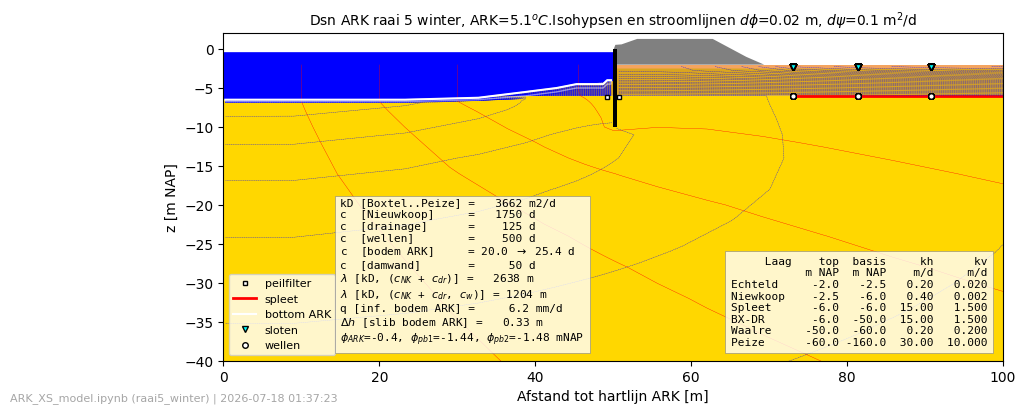

ark3D_r5_winter.pdf


In [169]:
def get_patches(ax):
    for lg in lagen.index:
        rec = lagen.loc[lg]        
        ax.add_patch(mpatch.PathPatch(rec['path'], ec='none', fc=rec['fc']))
        
    ax.add_patch(mpatch.PathPatch(ARK_prof.path, fc='blue', ec='none', zorder=1))                          # ARK waterlichaam
    ax.add_patch(mpatch.Rectangle((+b_ARK, z_damw), +b_damw, 0 - z_damw, fc='k', ec='none', zorder=2))     # Damwand
    ax.add_patch(mpatch.Rectangle((-b_ARK, z_damw), -b_damw, 0 - z_damw, fc='k', ec='none', zorder=2))     # Damwand
    
    # Add Slib ARK    
    xm, zTop, zBot = gr.XM[mask_ARK_slib], gr.Z[:-1][mask_ARK_slib], gr.Z[1:][mask_ARK_slib]
    Ix = np.argsort(xm)
    verts = np.c_[np.r_[xm[Ix], xm[Ix[::-1]]], np.r_[zTop[Ix], zBot[Ix[::-1]]]]
    pth_ARK_slib = mpath.Path(verts, closed=True)
    if True:
        ax.add_patch(mpatch.PathPatch(pth_ARK_slib, fc='none', ec='white', alpha=0.5, zorder=4))
    
    # --- Add Kade.
    zb = lagen.loc['Ech', 'bkLaag']
    zkade =         np.array([zb, -0.26, 0.54, 0.6, 1.3,  1.3, -1.0,   zb,   zb])    
    xkade = b_ARK + np.array([0., 0.00, 0.30, 1.1, 3.1, 12.8, 17.1, 19.4,  0. ])
    vertices = np.c_[xkade, zkade]    
    path = mpath.Path(vertices, closed=True)
    ax.add_patch(mpatch.PathPatch(path, fc='gray', ec='none', zorder=1))
    
# --- step size of isohypses and stream function lines
dphi, dpsi = 0.02, 0.1

# --- get the meta data
pbxy = atools.Peilbuizen(os.path.join(dirs.pb_imag, 'pb_tauw_XY.xlsx'), sheet_name='pbTauw')
pb_meta = pbxy.data

# --- get levels for  contouring
phi_min, phi_max = np.round(np.nanmin(out['Phi']) * 100) / 100, np.round(np.nanmax(out['Phi']) * 100) / 100
phi_levels = np.arange(phi_min, phi_max + dphi, dphi)

psi = gr.psi_row(out['Qx'], row=0) / gr.dy[0]  # Make psi for fow of 1 m wide
psi_min, psi_max = np.round(np.nanmin(psi) * 100) / 100, np.round(np.nanmax(psi) * 100) / 100
psi_levels = np.arange(psi_min, psi_max + dpsi, dpsi)

# --- View window
ylim = (None, 2)
xlim = (0, 600)

# --- Plot of cross section
fig, ax = plt.subplots(figsize=(12, 4.25))

# --- Patch to show layers in colors
get_patches(ax)

# --- Plot the two piezometers (both side of the sheet piling)
ax.plot(gr.XM[mask_pb], gr.ZM[mask_pb], 's', mfc='w', mec='k', lw=0.5, ms=3, label='peilfilter', zorder=11)

# --- Spleet / slot
xm = gr.XM[mask_spleet]
zm = gr.ZM[mask_spleet]
Ix = np.argsort(xm)
ax.plot(xm[Ix], zm[Ix], 'red', lw=2, label='spleet')

# --- Contour heads and stream lines
Phi = out['Phi']
Phi[mask_damw] = np.nan
Ch = ax.contour(gr.XM[:,0,:], gr.ZM[:,0,:], Phi[:, 0, :], levels=phi_levels, colors='b', linewidths=0.25)
Cp = ax.contour(gr.X[:,0,1:-1], gr.Z[:, 0, :-1], psi, levels=psi_levels, colors='r', linewidths=0.25)

# --- Compute the analytical properties of this aquifer
kD, c, cGHB, cDRN = get_analytical_props(gr, lagen, GHB, DRN)
c_cov = c + cGHB
c_tot = 1/(1/c_cov + 1/cDRN)
lam_top = np.sqrt(kD * c_cov).round()
lam_tot = np.sqrt(kD * c_tot).round()

# --- Infiltration computed from Delta_h and resistance
Ig_N = gr.NOD[mask_ARK_slib_N & (gr.YM == gr.ym[ 0])]
Ig_S = gr.NOD[mask_ARK_slib_S & (gr.YM == gr.ym[-1])]

xm_N = gr.XM[mask_ARK_slib_N & (gr.YM == gr.ym[ 0])]
xm_S = gr.XM[mask_ARK_slib_S & (gr.YM == gr.ym[-1])]

Ix_N = np.argsort(xm_N)
Ix_S = np.argsort(xm_S)

Ig_N = Ig_N[Ix_N] # Sorted global indices of slib layer, north edge of model
Ig_S = Ig_S[Ix_S] # Sorted global indices of slib layer, south edge of model

phi_top_N = out['Phi'].ravel()[Ig_N - gr.nx]
phi_top_S = out['Phi'].ravel()[Ig_S - gr.nx]

phi_bot_N = out['Phi'].ravel()[Ig_N + gr.nx]
phi_bot_S = out['Phi'].ravel()[Ig_S + gr.nx]

Delta_h_N = phi_top_N - phi_bot_N
Delta_h_S = phi_top_S - phi_bot_S

Dz_N = gr.DZ.ravel()[Ig_N]
Dz_S = gr.DZ.ravel()[Ig_S]

c_ARK_slib_N = gr.DZ.ravel()[Ig_N] / kv.ravel()[Ig_N]
c_ARK_slib_S = gr.DZ.ravel()[Ig_S] / kv.ravel()[Ig_S]

Qinf_N = Delta_h_N / c_ARK_slib_N
Qinf_S = Delta_h_S / c_ARK_slib_S

qinf_N = Qinf_N / b_ARK
qinf_S = Qinf_S / b_ARK

# --- Plot the location of the bottom sludge resistance
xm, zTop, zBot = gr.XM.ravel()[Ig_N], gr.Z[:-1].ravel()[Ig_N], gr.Z[1:].ravel()[Ig_N]
# verts = np.c_[np.r_[xm, xm[::-1]], np.r_[zTop, zBot[::-1]]]
# pth_ARK_slib = mpath.Path(verts, closed=True)
# ax.plot(*verts.T, 'w-', lw=0.5, zorder=5)
ax.plot(xm, zTop, 'w', label='bottom ARK')

# --- Infiltration directly form the model
Qinf_N = out['Q'][mask_ARK & (gr.YM == gr.ym[0])] / gr.dy[0]
qinf_N = Qinf_N.sum() / b_ARK

Qinf_S = out['Q'][mask_ARK & (gr.YM == gr.ym[-1])] / gr.dy[-1]
qinf_S = Qinf_S.sum() / b_ARK


# --- GHB (sloten)
mask_GHB = gr.const(0, dtype=bool)
mask_GHB.ravel()[GHB['Ig']] = True
ax.plot(gr.XM[mask_GHB], gr.ZM[mask_GHB], 'v', lw=0.5, ms=4, mfc='aqua', mec='k', label='sloten')

# --- DRN (wellen)
mask_DRN = gr.const(0, dtype=bool)
mask_DRN.ravel()[DRN['Ig']] = True
ax.plot(gr.XM[mask_DRN], gr.ZM[mask_DRN], 'o', lw=0.5, ms=4, mfc='w', mec='k', label='wellen')


cNK = lagen.loc['NK', 'D'] / lagen.loc['NK', 'kv']
c3  = 1/(1/(cNK + cGHB) + 1 / cDRN)
phi_pb = out['Phi'][mask_pb]
prop_txt = [
    f"kD [Boxtel..Peize] = {kD:6.0f} m2/d",
    f"c  [Nieuwkoop]     = {cNK:6.0f} d",
    f"c  [drainage]      = {cGHB:6.0f} d",
    f"c  [wellen]        = {cDRN:6.0f} d",
   rf"c  [bodem ARK]     = {c_ARK_slib:.1f} $\to$ {c_ARK_slib * mu_rel:.1f} d",
    f"c  [damwand]       = {c_damw:6.0f} d",
    fr"$\lambda$ [kD, ($c_{{NK}}$ + $c_{{dr}}$)] = {lam_top:6.0f} m",
    fr"$\lambda$ [kD, ($c_{{NK}}$ + $c_{{dr}}$, $c_w$)] = {lam_tot:.0f} m",
    f"q [inf. bodem ARK] =  {qinf_N * 1000:6.1f} mm/d",
    fr"$\Delta h$ [slib bodem ARK] = {Delta_h_N.mean():6.2f} m",
    fr"$\phi_{{ARK}}$={h_ARK:.1f}, $\phi_{{pb1}}$={phi_pb[0]:.2f}, $\phi_{{pb2}}$={phi_pb[1]:.2f} mNAP"
]

# fig.suptitle(supttl,  fontsize=10)
ttl = [fr"Dsn ARK raai {case[0]} {case[1]}, ARK={temp_ARK:.1f}$^oC$",
       fr"Isohypsen en stroomlijnen $d\phi$={dphi} m, $d\psi$={dpsi} m$^2$/d"
]

detail = False
if detail:
    x1, y1 = 0.98, 0.8
    x2, y2 = 0.98, 0.3
    ha, va = 'right', 'top'
    transform = fig.transFigure
    xlim = (0, 100)
    bowt_str = f'owt{b_owt:.0f}'
    fname = f"xs_ark_r{case[0]}_{case[1]}_{bowt_str}_detail.pdf"
    fig.set_size_inches(7, 5.25)
    ax.set_title('\n'.join(ttl), fontsize=10)
    pos = ax.get_position()    
    ax.set_position([0.01, pos.y0, pos.width, pos.height])
else:
    x1, y1 = 0.15, 0.04
    x2, y2 = 0.98, 0.04
    transform = ax.transAxes
    ha, va = 'left', 'bottom'
    fname = f"ark3D_r{case[0]}_{case[1]}.pdf"
    fig.set_size_inches(12, 4.25)
    ax.set_title('.'.join(ttl), fontsize=10)
    
ax.text(
    x1, y1, '\n'.join(prop_txt),
    transform=transform,
    ha=ha, va=va,
    family='monospace',
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor='0.5', linewidth=0.5, alpha=0.8),
    zorder=10,
)

ax.text(
    x2, y2, '\n'.join(strat_txt),
    transform=transform,
    ha='right', va='bottom',
    family='monospace',
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor='0.5', linewidth=0.5, alpha=0.8),
    zorder=10,
)

ax.set_xlabel('Afstand tot hartlijn ARK [m]')
ax.set_ylabel('z [m NAP]')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlim(0, 100)
ax.set_ylim(-40, 2)
ax.set_aspect(1)
ax.legend(loc="lower left", fontsize=8)

logo(fig, NOTEBOOK_NAME + f' (raai{case[0]}_{case[1]})')

# --- Spy where mask_ARK and mask_ARK_slib are
# ax.plot(gr.XM[mask_ARK], gr.ZM[mask_ARK], 'ks', zorder=100)
# ax.plot(gr.XM[mask_ARK_slib], gr.ZM[mask_ARK_slib], 'y*', zorder=100)

plt.show()
fig.savefig(os.path.join(dirs.images, fname))
print(fname)
# TODO

# Get head below target resistance and below actual resistance

Target bottom resistance is set to 100 d over mask_ARK_slib_N
Actual bottom resistance is set to c actual over mask_ARK_slib_S

In [165]:
gr.zm[iz]

np.float64(-6.005)

Layer 13 with zm = -7.25 mNAP


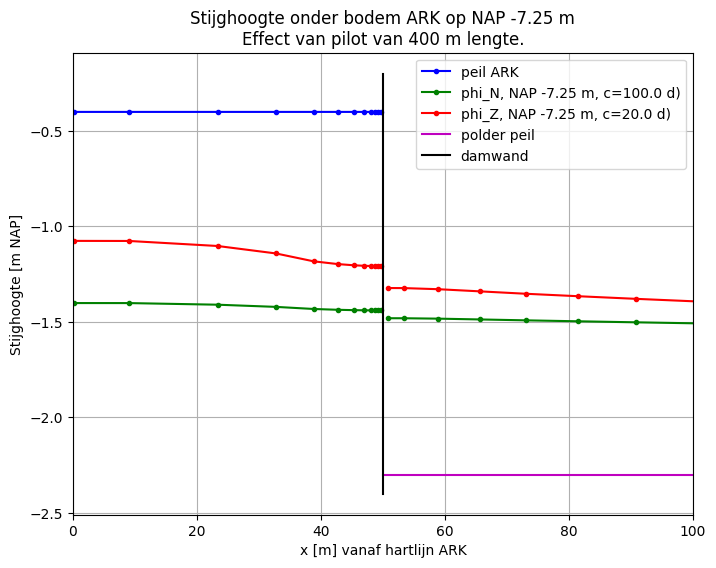

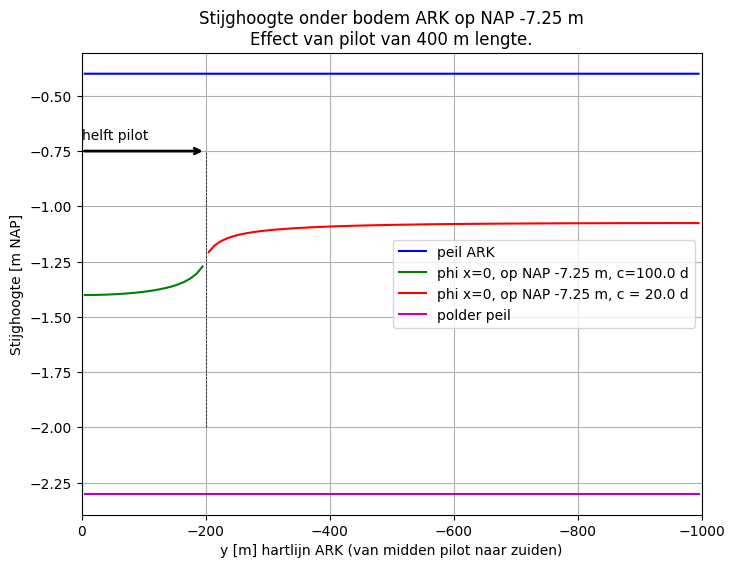

In [170]:
# Depth of piezometer (in sand below ARK, about -7.25)

iz = np.searchsorted(-gr.z, 7.5) - 1
z_phi = gr.zm[iz]
print(f"Layer {iz} with zm = {z_phi} mNAP")
mask_T = (gr.ZM==gr.zm[3]) & (gr.XM < b_ARK) & (gr.YM == gr.ym[ 0])   # --- ARK at north edge of model
mask_N = (gr.ZM==z_phi)    & (gr.XM < b_model) & (gr.YM == gr.ym[ 0]) # --- North edge of model
mask_S = (gr.ZM==z_phi)    & (gr.XM < b_model) & (gr.YM == gr.ym[-1]) # --- South edge of model


fig, ax = plt.subplots(figsize=(8,6))
ttl = (f"Stijghoogte onder bodem ARK op NAP {gr.zm[iz]:.2f} m" +"\n" +
       f"Effect van pilot van {2*(gr.y[0]-y_mid):.0f} m lengte.")
ax.set_title(ttl)
ax.set_xlabel("x [m] vanaf hartlijn ARK")
ax.set_ylabel("Stijghoogte [m NAP]")
ax.grid('both')

ax.plot(gr.XM[mask_T], out['Phi'][mask_T], 'b.-', label='peil ARK' )
ax.plot(gr.XM[mask_N], out['Phi'][mask_N], 'g.-', label=f'phi_N, NAP {z_phi:.2f} m, c={c_ARK_slib_goal} d)' )
ax.plot(gr.XM[mask_S], out['Phi'][mask_S], 'r.-', label=f'phi_Z, NAP {z_phi:.2f} m, c={c_ARK_slib} d)' )

ax.plot([b_ARK, b_model], [h_pold, h_pold], 'm', label='polder peil')
ax.plot([b_ARK, b_ARK], [h_pold - 0.1, h_ARK + 0.2], 'k', label='damwand') # --- Add sheet piling

ax.set_xlim(0, 2 * b_ARK)
ax.legend()
plt.show()

fname = f"h_x_L{gr.y[0]-gr.y[-1]}_ymid{y_mid:.0f}_NAP{z_phi*100:.0f}cm_{c_ARK_slib:.0f}_{c_ARK_slib_goal:.0f}.pdf"
fig.savefig(os.path.join(dirs.images, fname))

# --- Along the heart line
mask_TL = (gr.ZM==gr.zm[3]) & (gr.XM == gr.xm[0])
mask_NL = (gr.ZM==z_phi) & (gr.XM == gr.xm[0])
mask_SL = (gr.ZM==z_phi) & (gr.XM == gr.xm[0])

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(ttl)
ax.set_xlabel("y [m] hartlijn ARK (van midden pilot naar zuiden)")
ax.set_ylabel("Stijghoogte [m NAP]")
ax.grid('both')
ax.plot(gr.YM[mask_TL], out['Phi'][mask_TL], 'b-', label='peil ARK' )
ax.plot(gr.YM[mask_SL & (gr.YM >= y_mid)], out['Phi'][mask_SL & (gr.YM >= y_mid)], 'g-',
        label=f'phi x=0, op NAP {z_phi:.2f} m, c={c_ARK_slib_goal} d' )
ax.plot(gr.YM[mask_SL & (gr.YM <= y_mid)], out['Phi'][mask_SL & (gr.YM <= y_mid)], 'r-',
        label=f'phi x=0, op NAP {z_phi:.2f} m, c = {c_ARK_slib} d' )
ax.plot(gr.YM[mask_TL][[0, -1]], [h_pold, h_pold], 'm', label='polder peil')

ax.annotate('',
            xy=(0, -0.75),
            xytext=(y_mid, -0.75),
            arrowprops=dict(arrowstyle='<-', color='k', lw=2)
            )
ax.text(0, -0.7, 'helft pilot')
ax.plot([y_mid, y_mid], [-2.0, -0.75], 'k', lw=0.5, ls='--')

ax.set_xlim(gr.y[0], gr.y[-1])
ax.legend()
plt.show()

fname = f"h_y_L{gr.y[0]-gr.y[-1]}_ymid{y_mid:.0f}_NAP{z_phi*100:.0f}cm_{c_ARK_slib:.0f}_{c_ARK_slib_goal:.0f}.pdf"
fig.savefig(os.path.join(dirs.images, fname))


In [157]:
gr.YM[mask_SL & (gr.YM > y_mid)]

array([ -5., -15., -25., -35., -45., -55., -65., -75., -85., -95.])

fname = frac_Q_in_spleet_3D.pdf
file fractie_in_spleet_3D.pdf saved


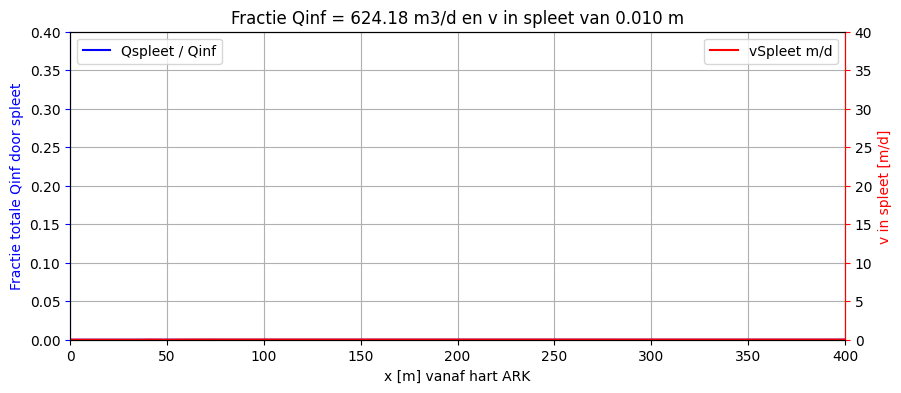

In [80]:
iz = gr.iz_below(lagen.loc['NK', 'okLaag'])

dSpleet = gr.dz[iz]
Qspleet = out['Qx'][iz, 0]
Qfrac = Qspleet / Qinf.sum()
vSpleet = Qspleet / dSpleet # m/d 

fig, ax = plt.subplots(figsize=(10, 4))

ax.set_title(f"Fractie Qinf = {Qinf.sum():.2f} m3/d en v in spleet van {gr.dz[iz]:.3f} m")
ax.set(xlabel='x [m] vanaf hart ARK', ylabel='Fractie totale Qinf door spleet')
ax.grid(True, axis='both') # Horizontale gridlijnen

ax.plot(gr.X[iz, 0, 1:-1], Qfrac, 'b', label='Qspleet / Qinf')

ax.tick_params(axis='y', color='b')
ax.spines['left'].set_color('b')
ax.yaxis.label.set_color('b')
ax.set_ylim(0, 0.40)

ax2 = ax.twinx()
ax2.plot(gr.X[iz, 0, 1:-1], vSpleet, 'r', label='vSpleet m/d')

ax2.set_ylabel('v in spleet [m/d]', color='r')

# --- Make right axis red
ax2.tick_params(axis='y', color='r')
ax2.spines['right'].set_color('r')
ax2.yaxis.label.set_color('r')

# --- Make sure both sides have the same number of ticks
ax2.set_ylim(0, 35)
ax2.set_yticks(np.linspace(0, 40, 9))
ax.set_xlim(0, 400)

ax.legend(loc='upper left')
ax2.legend(loc='upper right')

fname = 'frac_Q_in_spleet_3D.pdf' 
fig.savefig(os.path.join(dirs.images, fname))
print(f"fname = {fname}")

fname = 'fractie_in_spleet_3D.pdf'
fig.savefig(os.path.join(dirs.images, fname))
print(f"file {fname} saved")


## Logging specific results to compare different model runs

The results are logged in a file "model_log.csv"in dirs.data

If you load this file in a VScode window, you can see what's in as it's updated
after each run of the cell below.

In that window, you can simply put a header line on top by hand.

In [81]:
fname = "model_log_3D.csv"
fpath = os.path.join(dirs.data, fname)

csv_hdr = "datetime,temp,qinf,b_owt,c_damw,c_ARK,cARK[T],Phi[1],Phi[2]".split(',')

print(' '.join([f"{s:>6}" for s in csv_hdr]))

# --- If the file does not yet exist save the csv header
try:
    with open(fpath, 'r') as f:
        pass
except Exception:
    with open(fpath, 'w') as f:
        f.write("qinf,b_owt,c_ARK,Phi[1],Phi[2])" + '\n')

# --- Get the items to be viewed and saved after each model run:
now_str = pd.Timestamp.now().floor("min").strftime("%Y-%m-%d %H:%M")
items = [now_str,
         temp_ARK,
         (qinf.mean()*1000).round(1),
         round(b_owt, 1),         
         round(c_damw,1),
         round(c_ARK_slib,1),
         round(c_ARK_slib * mu_rel, 1),
         round(out['Phi'][mask_pb][0], 3),
         round(out['Phi'][mask_pb][1], 3)
         ]

with open(fpath, 'a') as f:    
    ln = ','.join([f"{item}" for item in items])    
    f.write(ln + '\n')
    print(ln)
    
# Look in the window with the log file open

datetime   temp   qinf  b_owt c_damw  c_ARK cARK[T] Phi[1] Phi[2]
2026-07-17 22:25,5.1,12483.5,19.2,50.0,20.0,25.4,-1.788,-1.798


# Plot meaurements and model heads to the west of ARK for rows 4, 5, and 6

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6.5))

# --- We want the head along the top of the first and second aquifers
iz_ARK    = gr.iz_above(z_ARK)
iz_subARK = gr.iz_below(z_ARK) # Just below the sludge layer
iz_echtel = gr.iz_below(lagen.loc['Ech', 'bkLaag'])
iz_top_NK = gr.iz_below(lagen.loc['NK', 'bkLaag'])
iz_top_BX = gr.iz_below(lagen.loc['BX', 'bkLaag'])
iz_bot_BX = gr.iz_above(lagen.loc['BX', 'okLaag'])
iz_top_Pe = gr.iz_below(lagen.loc['Pe', 'bkLaag'])
iz_bot_Pe = gr.iz_above(lagen.loc['Pe', 'okLaag'])

sloten = gr.const(0, dtype=bool)
sloten.ravel()[GHB['Ig']] = True

wellen = gr.const(0, dtype=bool)
wellen.ravel()[DRN['Ig']] = True

ark    = (gr.ZM == iz_ARK)           & (gr.XM < b_ARK)
echtel = (gr.ZM == gr.zm[iz_echtel]) & (gr.XM > b_ARK + b_damw)
top_NK = (gr.ZM == gr.zm[iz_top_NK]) & (gr.XM > b_ARK + b_damw)
top_BX = (gr.ZM == gr.zm[iz_top_BX]) & (gr.XM > b_ARK + b_damw)
subARK = (gr.ZM == gr.zm[iz_subARK]) & (gr.XM < b_ARK)
bot_BX = (gr.ZM == gr.zm[iz_bot_BX])
top_Pe = (gr.ZM == gr.zm[iz_top_Pe])
bot_Pe = (gr.ZM == gr.zm[iz_bot_Pe])

# --- setup ---
lw = 0.5
model_side = 'W'
yscale = 'linear'


ax.set_yscale(yscale)
if ax.get_yscale() == 'log':
    hpp = h_pold
else:
    hpp = 0    

if model_side == 'W':
    sign = -1

ax.plot(sign * gr.XM[ark],    out['Phi'][ark],                   -hpp, 'b', label=f'ark        NAP {gr.zm[iz_ARK   ]:6.1f} m')
ax.plot(sign * gr.XM[subARK], out['Phi'][subARK],                -hpp, lw=lw,  label=f'onder ARK  NAP {gr.zm[iz_subARK]:6.1f} m')
ax.plot(sign * gr.XM[sloten], h_pold * np.ones(len(GHB))        -hpp,  'v', lw=0.5, mfc='aqua', mec='k',  label=f'slootpeil   NAP {h_pold:6.1f} m')
ax.plot(sign * gr.XM[wellen], h_pold * np.ones(len(DRN)) - 0.025 -hpp, 'o', lw=0.5, mfc='none', mec='k',  label=f'wellen      NAP {h_pold:6.1f} m')
ax.plot(sign * gr.XM[echtel], out['Phi'][echtel]                 -hpp, lw=lw,  label=f'Echteld    NAP {gr.zm[iz_echtel]:6.1f} m')
ax.plot(sign * gr.XM[top_NK], out['Phi'][top_NK]                 -hpp, lw=lw,  label=f'top NKoop  NAP {gr.zm[iz_top_NK]:6.1f} m')
ax.plot(sign * gr.XM[top_BX], out['Phi'][top_BX]                 -hpp, lw=lw * 3,  label=f'top BX-DR NAP {gr.zm[iz_top_BX]:6.1f} m')
ax.plot(sign * gr.XM[bot_BX], out['Phi'][bot_BX]                 -hpp, lw=lw,  label=f'bot_BX-DR NAP {gr.zm[iz_bot_BX]:6.1f} m')
ax.plot(sign * gr.XM[top_Pe], out['Phi'][top_Pe]                 -hpp, lw=lw,  label=f'top Peize  NAP {gr.zm[iz_top_Pe]:6.1f} m')
ax.plot(sign * gr.XM[bot_Pe], out['Phi'][bot_Pe]                 -hpp, lw=lw,  label=f'bot Peize  NAP {gr.zm[iz_bot_Pe]:6.1f} m')

if ax.get_yscale()=='log':
    ax.set_title(f"Stijghoogte op horizontale vlakken voor raai {case[0]} {case[1]}")
    ax.set_xlabel('x > hart ARK')    
    ax.set_ylabel('Stijghoogte [m NAP]')
    ax.set_ylim(4e-2, 1e1)
else:
    ax.set_title(fr"Raai {case[0]} {case[1]}, ARK_temp={temp_ARK:.1f}$^o$C: Stijghoogte op horizontale vlakken en metingen.")
    ax.set_xlabel('x > hart ARK')
    ax.set_ylabel('Stijgh - polderpeil [m]')
    

xlim = (-b_model/10, b_model/10)
# xlim = (0, b_model)
ax.set_xlim(xlim)
ax.legend()

x1, x2, y = b_ARK + b_kade, b_ARK + b_kade + b_wellen, 2 if ax.get_yscale()=='log' else -2.5
x1 *= sign
x2 *= sign
ax.annotate('',
            xy=(x1,y),
            xytext=(x2,y),
            arrowprops=dict(arrowstyle='|-|', lw=1, color='red')
)
ax.text(0.5 * (x1 + x2), y,
        'wellen',
        ha='center', va='bottom')

ax.vlines([-b_ARK, b_ARK], ymin=-2.75, ymax=-0.25, colors=['k'], linewidths=0.5, linestyles='--')
ax.hlines([-0.4], xmin=-b_ARK, xmax=+b_ARK, colors='b', linewidths=0.5,  linestyles='--')

ax.text(0.02, 0.98, '\n'.join(strat_txt),
    transform=ax.transAxes,
    ha='left', va='top',
    family='monospace',
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor='0.5', linewidth=0.5, alpha=0.8)
)

ax.text(
    0.98, 0.02, '\n'.join(prop_txt),
    transform=ax.transAxes,
    ha='right', va='bottom',
    family='monospace',
    fontsize=8,
    bbox=dict(facecolor='white', edgecolor='0.5', linewidth=0.5, alpha=0.8)
)

ax.grid(True)
ax.legend(loc='upper right', fontsize=8)

logo(fig, NOTEBOOK_NAME + f' (raai{case[0]}_{case[1]})')

# === Add heads measured in cross sections perpendicular to the ARK
if True:
    if case[1] == 'winter':
        pass
    raaien = [4, 5, 6]
        
    for raai in np.unique(pb_meta['raai']):
        if raai not in raaien:
            continue
        for WE in ['W', 'E']:                    
            for tcol in ['summer', 'winter']:
                mask = (pb_meta['raai'] == raai) & (pb_meta['WE'] == WE) & (pb_meta[tcol] != 0)
                print(f"raai{raai}, WE={WE}, tcol={tcol}, sum(mask)={np.sum(mask)}")
                n = np.sum(mask)
                if n < 1:
                    continue
                x = pb_meta.loc[mask, 'dist'].values
                y = pb_meta.loc[mask, tcol].values
                
                if WE == 'W':
                    sign = -1  # For now all on the positive x-axis
                    label=f"raai={raai}, {tcol}"                
                else:
                    sign = +1
                    label=""                
                    
                if tcol == 'summer':
                    ls = '--'
                else:
                    ls = '-'
                                
                    
                if n == 1:
                    ax.plot(sign * x, y, 'o', ms=4, color=raai_colors[raai - 1], label=label)
                    pass
                else:
                    if tcol == tcol[1]:
                        lw = 2
                    else:
                        lw = 1
                    ix = np.argsort(x)
                    ax.plot(sign * x[ix], y[ix], marker='o', ms=4, ls=ls, color=raai_colors[raai - 1], lw=lw, label=label)


ax.grid(True)
ax.legend(loc='upper right', fontsize=8)

logo(fig, NOTEBOOK_NAME + f' (raai{case[0]}_{case[1]})')

plt.show()

if ax.get_yscale() == 'log':
    fname = f"stijgh_log_xs_ark_raai{case[0]}_{case[1]}.pdf"
else:
    fname = f"stijgh_xs_ark_raai{case[0]}_{case[1]}.pdf"
fig.savefig(os.path.join(dirs.images, fname))


print(fname)
fig.savefig(os.path.join(dirs.images, fname))
# TODO

# Compute summer head based on winter head and temperatures

In [ ]:
pb_meta # --- The excel sheet with peilbuis meta data

In [ ]:
pb = pd.DataFrame()

# --- pb_meta comes from above from Excel file with the meta peilbuis data
pb_meta = pb_meta.astype(dtype={'raai':int,
                                'dist':float,
                                'summer':float,
                                'winter':float,
                                'ZP':float,
                                'WP':float
                                }
                         )

# --- There are 13 transects for each transect we select wells close by with actual data
for raai in range(14):
    pb = pd.concat((
        pb, pb_meta[['raai', 'dist', 'summer', 'winter', 'ZP', 'WP']][
            (pb_meta['raai']==raai) & 
            (pb_meta['dist'] < 200.) &
            (pb_meta['WE']=='W') & 
            (pb_meta['summer'] !=0.) & (pb_meta['winter'] !=0.)])
    )
    
# --- Summer minus winter heads
pb['Z-W']=pb['summer'] - pb['winter']
pb['sum'] = np.nan


Tw, Ts = temp_ARK_stats['winter']['temp'], temp_ARK_stats['summer']['temp']
Tw, Ts = temp_ARK_stats['min']['temp'], temp_ARK_stats['max']['temp']

mu_ratio = muT_mu10C(Ts) / muT_mu10C(Tw)
h_ARK = -0.4

fig, ax = plt.subplots(figsize=(10., 10.))
s = "Vergelijking gemeten en berekende zomer stijghoogts voor "
ax.set_title(s + fr"$T_{{winter}}$={Tw} en $T_{{zomer}}$={Ts} C")
ax.set_ylabel("gemeten stijghoogte winter [m NAP]")
ax.set_xlabel("berekende stijghoogte zomer [m NAP]")

# --- Other outligning to prevent overlap of labels on plot
pb['ha'] = 'center'
pb.loc[[603, 903], 'ha'] = 'right'
pb.loc[[101, 802, 1003], 'ha'] = 'left'

# --- Tabel header
print(f"{'name':>6} {'h_ARK':>6} {'hTr':>6} {'hp':>6} {'Tw':>6} {'Ts':6} " +
      f"{'mu_rat':>6} {'q_rat':>6} {'hT1':>6} {'hT2':>6} {'hTs':>6} {'hTs-hT1'}"
      )

for i, name in enumerate(pb.index):
    rec = pb.loc[name]
    raai = int(rec['raai'])    
    hp = rec['WP']
    hTw = rec['winter']
    hTs  = rec['summer']
    dist = rec['dist']
    
    q_ratio = (h_ARK - hp) / ((h_ARK - hTw) * mu_ratio + (hTw - hp))
    
    # --- Two ways to calculate hTs, which must be the same
    hT1 = hp + q_ratio * (hTw - hp)
    hT2 = hp + (h_ARK - hp) / ((h_ARK - hTw)/(hTw - hp) * mu_ratio + 1)
    
    # --- col 'sum' is the computed summer head
    pb.loc[name, 'sum'] = hT2.round(3)
    
    # --- Table lines
    print(f"{name:>6} {h_ARK:6.3f} {hTw:6.3f} {hp:6.3f} {Tw:6.2f} {Ts:6.3f} " +
          f"{mu_ratio:6.3f} {q_ratio:6.3f} {hT1:6.3f} {hT2:6.3f} " +
          f"{hTs:6.3f} {hTs - hT1:6.3f}"
          )

    ax.plot(hT1, hTs - 0.01, 'o', mfc=leg_colors[raai], ms=10, mec='k', label='name')
    ax.text(hT1, hTs, f"pb{name}\n{dist:.0f}m", ha=rec['ha'], va='bottom')

# --- Line under 1:1 to compare results
ax.plot([-1.7, -0.9], [-1.7, -0.9])

ax.set_xlim(None, -0.8)
ax.set_ylim(None, -0.8)
ax.grid()

logo(fig, NOTEBOOK_NAME)

fig.savefig(os.path.join(dirs.images, f'ber_vs_gem_zomer_stijghoogen_T{Tw:.0f}_{Ts:.0f}.pdf'))

plt.show()

# Compare the head in the Boxtel layer in the model with the analytical solution

In [ ]:
print(f"lam_tot={lam_tot} lam_top={lam_top}")

# --- Collect the data for the analytic comparison

# --- Totale instroom vanuit ARK en infiltratieflux
Q = out['Q'][IBOUND==-1].sum()
q = Q / b_ARK
print(f"Q={Q:.2f}, q={q:4f}")

# ---- Stijghoogte basis boxtel ten opzichte van polderpeil
phiBX = out['Phi'][bot_BX] - h_pold
xBX = gr.XM[bot_BX]

# --- Berekening met nsec1 ----
# --- Secties baseren op 4 punten
Xp = np.array([b_ARK,
               b_ARK + b_kade,
               b_ARK + b_kade + b_wellen,
               500.,
               b_model])

# --- Randvoorwaarden
Qp = [-Q, 0., 0., 0., 0.]
Phi = [np.nan, h_pold]

L = np.diff(Xp)
h = np.ones_like(L) * h_pold
c = np.array([lam_tot, # --- met wellen
              lam_tot, # --- met wellen
              lam_top, # --- zonder wellen
              lam_top]) ** 2 / kD

# --- the nsec1 model
nsec1 = Nsec1(L=L, kD=np.array([kD, kD, kD, kD]), c=c, X0=b_ARK)

# --- Resulaten
outx = nsec1.simulate(Phi=Phi, Q=Qp, h=h)
outp = nsec1.simulate(Phi=Phi, Q=Qp, h=h, x=nsec1.X)

# --- Plotten
fig, ax = plt.subplots(figsize=(10, 8))
# ---- De analytische oplossing van nsec1
ax.plot(nsec1.x, outx['phi'] - h_pold, label='phi1_analytical')
ax.plot(Xp, outp['phi'] - h_pold, 'ro', mec='k',  label='phi1_analytical')

# --- Model resultaten
ax.plot(gr.XM[top_BX], out['Phi'][top_BX] - h_pold, '.', label='model top_BX')
ax.plot(gr.XM[bot_BX], out['Phi'][bot_BX] - h_pold, '.', label='model bot_BX')
ax.plot(gr.XM[top_Pe], out['Phi'][top_Pe] - h_pold, '.', label='model top Pe')

tln = f"c_ARK_slib={c_ARK_slib:.1f} d, q = {q*1e3:.1f} mm/d, phi_Bx_bot = {out['Phi'][bot_BX][0] - h_pold:.2f} m, phi_Bx Anal={outp['phi'][0] - h_pold:.2f}"

# --- Afronding ---
ax.grid(True)
ax.set_title(f"Comp. of model with anal. solution, Q={Q:.2} m2/d, raai {case[0]} {case[1]}, temp_ARK={temp_ARK}" + "\n" + tln)

ax.set_ylabel('head [m]')
ax.set_xlabel('x [m]')
ax.set_yscale('log')
ax.set_xlim(0, 10000)
ax.set_ylim(None, None)
ax.legend()
# Plot all  summer and winter data 
fig, ax = plt.subplots(figsize=(12, 8.5))

ax.set_xlabel('x > hart ARK')
ax.set_ylabel('Head [m NAP]')

# === Add heads measured in cross sections perpendicular to the ARK

for raai in np.unique(pb_meta['raai']):
    # if raai not in [case[0]]: # [4, 5, 6, 11]:
    #    continue
    for WE in ['W', 'E']:
        for tcol in ['summer', 'winter']:
            mask = (pb_meta['raai'] == raai) & (pb_meta['WE'] == WE) & (pb_meta[tcol] != 0)
            print(f"raai{raai}, WE={WE}, tcol={tcol}, sum(mask)={np.sum(mask)}")
            n = np.sum(mask)
            if n < 1:
                continue
            x = pb_meta.loc[mask, 'dist'].values
            y = pb_meta.loc[mask, tcol].values
            
            if WE == 'W':
                x = -x  # For now all on the positive x-axis
                label=f"raai={raai}, {tcol}"                
            else:
                label=""                
                
            if tcol == 'summer':
                ls = '--'
            else:
                ls = '-'
                            
                
            if n == 1:
                ax.plot(x, y, 'o', ms=4, color=raai_colors[raai - 1], label=label)
                pass
            else:
                if tcol == tcol[1]:
                    lw = 2
                else:
                    lw = 1
                ix = np.argsort(x)
                ax.plot(x[ix], y[ix], marker='o', ms=4, ls=ls, color=raai_colors[raai - 1], lw=lw, label=label)

ax.vlines([-b_ARK, b_ARK], ymin=-2.75, ymax=-0.25, colors=['k'])
ax.hlines([-0.4], xmin=-b_ARK, xmax=+b_ARK, colors='b')

ax.grid(True)
ax.legend(fontsize=8)

logo(fig, NOTEBOOK_NAME + f' (raai{case[0]}_{case[1]})')

plt.show()

fname = "stijgh_xs_ark_gemeten.pdf"
fig.savefig(os.path.join(dirs.images, fname))

# Use the analytic model to estimate what happen of kD is multiplied by a large facto over de arrea where there are wells



In [ ]:
# --- the nsec1 model
X = np.array([0, 50, 350, 10000.])
kD = [1000., 1000., 1000.]
L  = np.diff(X)
c  = [25., 250., 1000.]

h_ARK, h_pold = -0.4, -2.1
b_ARK = 50.

# --- Polderpeilen
h =  [h_ARK, h_pold, h_pold]

# --- Instantiate the model
mdl = Nsec1(L=L, kD=kD, c=c, X0=0)

# --- Head boundary conditions
Phi = [np.nan, np.nan]

# --- Q boundary conditions
Q= np.zeros(len(L) + 1)

# --- Coordinates to plot
x = np.logspace(-3, np.log10(X[-1]), 81)

# --- Set yscale 'log' or 'linear;
yscale = 'linear'
xlabel = 'x [m]'
xlim  = [0, 2000]

Temp = np.linspace(5., 25., 5)
mu_ratio = muT_mu10C(Temp) / muT_mu10C(14)

C0  = c[0]  * mu_ratio
kD0 = kD[0] / mu_ratio

for end_factor in [1, 2]:
    # --- Show results
    fig, ax = plt.subplots(figsize=(10, 6))

    # --- Let kD1 increase linearly with temp, using end_factor    
    kD1 = kD[1] * np.linspace(1, end_factor, len(Temp))

    # --- Set paramters that vary when running over times
    for c0, kd0, kd1, temp in zip(C0, kD0, kD1, Temp):
        mdl.c[ 0] = c0
        mdl.kD[0] = kd0
        mdl.kD[1] = kd1
        out = mdl.simulate(Phi, Q, h, x=x, Np=51)

        label = fr"temp={temp:.0f} $^o$C, c[0]={mdl.c[0]:.0f} d, kD[0]={mdl.kD[0]:.0f}, kD[1]={mdl.kD[1]:.0f} m$^2$/d"

        if yscale == 'linear':
            ax.plot(out['x'], out['phi'], label=label)
            ylabel = 'h [m NAP]'
        else:
            ax.plot(out['x'], out['phi'] - h_pold, label=label)
            ylabel = 'h - h_pold [m]'

    # --- Add polder levels
    ax.step(mdl.X[:-1], mdl.h, where='post', color='brown', label='polder peil')
    ax.plot(mdl.X[-2:], [mdl.h[-1], mdl.h[-1]], color='brown')

    # ---- Add verticals to show separate regions
    ax.vlines(mdl.X[1:], h_pold, h_ARK, ls='--', lw=1, colors='k')

    # --- Annotate
    shifty = -0.5
    ax.annotate('h[ARK]', (b_ARK/2, h_ARK), (100., h_ARK+ 0.5*shifty), textcoords='data',
        arrowprops={'arrowstyle':'->'})

    xwellen = mdl.X[1] + (mdl.X[1] + mdl.X[1]) / 2.

    ax.annotate('', (mdl.X[1], h_ARK+shifty), (mdl.X[2], h_ARK+shifty), textcoords='data',
        arrowprops={'arrowstyle':'<->'})

    ax.text(xwellen, h_ARK+shifty, 'wellen', ha='left', va='bottom')

    ax.set_title("Effect van viscositeit en spleetvorming op stijghoogte")
    ax.set_xlim(xlim)
    ax.grid('both')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)   
    ax.legend()

    logo(fig, NOTEBOOK_NAME)

    if end_factor == 1.:
        fname = "impact_visc_3D.pdf"    
    else:
        fname = "impact_visc_and_kD_3D.pdf"
        
    fig.savefig(os.path.join(dirs.images, fname))
    print(f'fig {fname} saved to images')
